### [ROC 곡선 직접 그려보기 — threshold 0.0~1.0 단계별 시각화] 

- 작은 예시 데이터(사과=1, 배=0)
- threshold를 0.0부터 1.0까지 0.1씩 변경하며 TPR/FPR을 직접 계산
- 그 점들을 이어서 ROC 곡선이 만들어지는 과정을 확인

- **[0]모듈로딩**

In [ ]:
## 모듈 로딩
import numpy as np

## 시각화 관련
import matplotlib.pyplot as plt
import koreanize_matplotlib

## ML 성능평가 관련
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

- **[1] 작은 예시 데이터 생성**
    - 샘플 10개 (사과=1, 배=0)에 대해, 모델이 예측한 "사과일 확률"(predict_proba) 가정
    - model.predict_proba(X_test)[:, 1]로 얻는 값

In [ ]:
## => 실제 정답 (1=사과, 0=배)
y_true = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

## => 모델이 예측한 "사과일 확률" (0~1)
y_proba = np.array([0.95, 0.85, 0.70, 0.55, 0.40,
                     0.60, 0.45, 0.30, 0.20, 0.10])

for t, p in zip(y_true, y_proba):
    label = '사과' if t == 1 else '배'
    print(f'실제: {label} (y={t})  ->  모델 예측 확률: {p:.2f}')

실제: 사과 (y=1)  ->  모델 예측 확률: 0.95
실제: 사과 (y=1)  ->  모델 예측 확률: 0.85
실제: 사과 (y=1)  ->  모델 예측 확률: 0.70
실제: 사과 (y=1)  ->  모델 예측 확률: 0.55
실제: 사과 (y=1)  ->  모델 예측 확률: 0.40
실제: 배 (y=0)  ->  모델 예측 확률: 0.60
실제: 배 (y=0)  ->  모델 예측 확률: 0.45
실제: 배 (y=0)  ->  모델 예측 확률: 0.30
실제: 배 (y=0)  ->  모델 예측 확률: 0.20
실제: 배 (y=0)  ->  모델 예측 확률: 0.10


- **[2] threshold 직접 적용**
    - 예) threshold = 0.5 라면, 확률 >= 0.5 인 샘플은 양성(사과)으로 판정
    - **TPR (True Positive Rate)** = TP / (TP + FN) → 실제 사과 중 맞게 잡아낸 비율
    - **FPR (False Positive Rate)** = FP / (FP + TN) → 실제 배 중 잘못 사과라고 한 비율

In [3]:
## ---------------------------------------------------------
## 함수이름 : compute_tpr_fpr
## 함수기능 : 임계값에 따른 TPR, FPR 계산 후 예측값 반환
## 매개변수 : y_true    - 정답
##           y_proba   - 확률값
##          threshold  - 임계값
## 함수결과 : TPR, FPR, 예측값
## ---------------------------------------------------------
def compute_tpr_fpr(y_true, y_proba, threshold):
    ## => threshold 이상이면 양성(1)으로 판정
    y_pred = (y_proba >= threshold).astype(int)

    ## => confusion matrix: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return tpr, fpr, y_pred



In [4]:
## 테스트
## => threshold = 0.5 일 때 확인
tpr, fpr, y_pred = compute_tpr_fpr(y_true, y_proba, 0.5)
print('threshold = 0.5')
print('예측 결과 :', y_pred)
print(f'TPR = {tpr:.2f},  FPR = {fpr:.2f}')

threshold = 0.5
예측 결과 : [1 1 1 1 0 1 0 0 0 0]
TPR = 0.80,  FPR = 0.20


- **[3] threshold를 0.0 ~ 1.0까지 0.1씩 변경하며 변화**
    - threshold가 낮아질수록(엄격함이 줄어들수록)
    - 더 많은 샘플을 양성으로 판정하게 되어 TPR과 FPR이 같이 올라감

In [5]:
## => 임계값 범위
thresholds_manual = np.round(np.arange(1.0, -0.1, -0.1), 2)  ## => 1.0 -> 0.0

## => 임계값 변환에 따른 TPR, FPR, 예측값 변화
results = []
for t in thresholds_manual:
    tpr, fpr, y_pred = compute_tpr_fpr(y_true, y_proba, t)
    results.append((t, fpr, tpr))

print(f"{'threshold':>10} | {'FPR':>6} | {'TPR':>6}")
print('-' * 30)
for t, fpr, tpr in results:
    print(f'{t:>10.1f} | {fpr:>6.2f} | {tpr:>6.2f}')

 threshold |    FPR |    TPR
------------------------------
       1.0 |   0.00 |   0.00
       0.9 |   0.00 |   0.20
       0.8 |   0.00 |   0.40
       0.7 |   0.00 |   0.60
       0.6 |   0.20 |   0.60
       0.5 |   0.20 |   0.80
       0.4 |   0.40 |   1.00
       0.3 |   0.60 |   1.00
       0.2 |   0.80 |   1.00
       0.1 |   1.00 |   1.00
       0.0 |   1.00 |   1.00


- **[4] 점을 찍고 이어서 ROC 곡선 그리기**
    - 표의 (FPR, TPR) 쌍 하나하나가 곡선 위의 점 하나
    - threshold가 다르면 점도 다르고, 이 점들을 순서대로 이으면 ROC 곡선이 됨

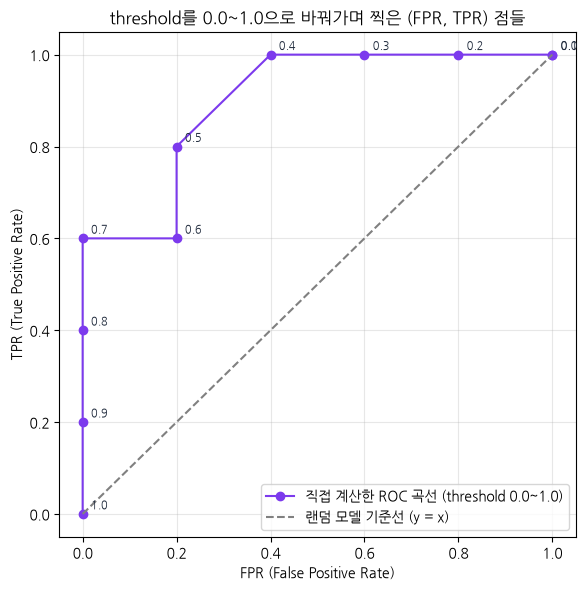

In [6]:
fpr_manual = [r[1] for r in results]
tpr_manual = [r[2] for r in results]

plt.figure(figsize=(6, 6))

## => 직접 계산한 점들을 이어서 그린 ROC 곡선
plt.plot(fpr_manual, tpr_manual, marker='o', color='#7C3AED',
         label='직접 계산한 ROC 곡선 (threshold 0.0~1.0)')

## => 각 점 옆에 threshold 값 표시
for t, fpr, tpr in results:
    plt.annotate(f'{t:.1f}', (fpr, tpr), textcoords='offset points',
                 xytext=(6, 4), fontsize=8, color='#1E293B')

## => 랜덤 모델 기준선 (대각선, AUC=0.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray',
         label='랜덤 모델 기준선 (y = x)')

plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('threshold를 0.0~1.0으로 바꿔가며 찍은 (FPR, TPR) 점들')
plt.legend(loc='lower right')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_manual.png', dpi=120)
plt.show()

- **[5] scikit-learn의 roc_curve() / roc_auc_score() 와 비교**
    - 직접 계산한 결과가 scikit-learn이 내부적으로 계산하는 것과 같은지 확인
    - scikit-learn은 데이터에 등장하는 고유한 확률값들을 threshold로 사용
    - 0.1 간격으로 직접 계산한 것보다 점이 더 촘촘할 수 있음

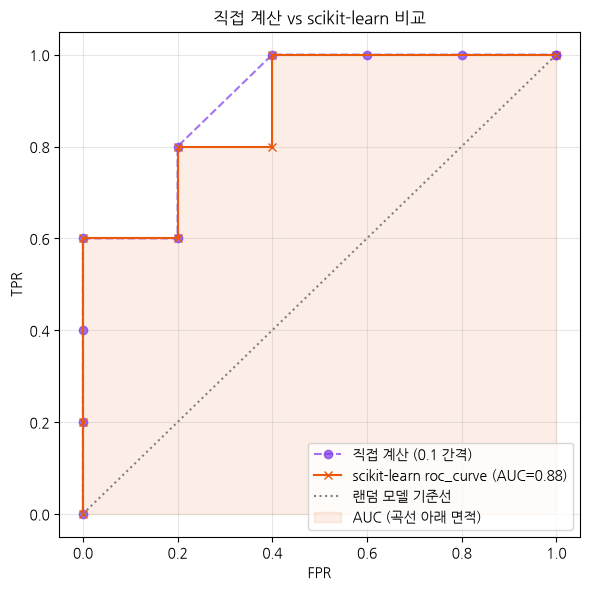

AUC (roc_auc_score) = 0.880


In [7]:
fpr_sklearn, tpr_sklearn, thresholds_sklearn = roc_curve(y_true, y_proba)
auc_score = roc_auc_score(y_true, y_proba)

plt.figure(figsize=(6, 6))

plt.plot(fpr_manual, tpr_manual, marker='o', color='#7C3AED',
         label='직접 계산 (0.1 간격)', linestyle='--', alpha=0.7)
plt.plot(fpr_sklearn, tpr_sklearn, marker='x', color='#EA580C',
         label=f'scikit-learn roc_curve (AUC={auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle=':', color='gray', label='랜덤 모델 기준선')

plt.fill_between(fpr_sklearn, tpr_sklearn, alpha=0.1, color='#EA580C',
                  label='AUC (곡선 아래 면적)')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('직접 계산 vs scikit-learn 비교')
plt.legend(loc='lower right')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_compare.png', dpi=120)
plt.show()

print(f'AUC (roc_auc_score) = {auc_score:.3f}')

### **[정리]**

- threshold를 1.0 → 0.0 으로 내릴수록 양성 판정이 늘어나 **TPR과 FPR이 함께 증가**합니다.
- 이때마다 찍히는 (FPR, TPR) 점들을 이은 것이 **ROC 곡선**입니다.
- 곡선이 **왼쪽 위 모서리에 가까울수록** (적은 FPR 희생으로 TPR이 빨리 오를수록) 좋은 모델입니다.
- **AUC**는 이 곡선 아래의 면적으로, 1.0에 가까울수록 좋고 0.5면 랜덤 모델과 동일합니다.
- 이번 예시는 데이터 10개뿐이라 곡선이 계단식으로 꺾이지만, 실제 데이터(수백~수천 개)에서는
  threshold 후보가 많아져 곡선이 더 부드럽게 보입니다.